
# Sequence-to-Sequence Models with Attention (Neural Machine Translation)

*A lecture note on how one recurrent network reads a sentence, another
recurrent network writes a translation of it, and why "writing" needs to be
able to look back at "reading" wherever it wants.*

---

## 1. Intro: why translation can't just be a bigger sequence tagger

This domain's earlier tutorials on **RNN/LSTM language modeling** and on
**sequence labeling** (POS tagging, named entity recognition) all share a
convenient property: the output is aligned one-to-one with the input. A
language model predicts one next-word distribution per input step; a POS
tagger emits exactly one tag per input token, in the same order the tokens
arrived. Whatever recurrent machinery updates the hidden state, the *output
schedule* is fixed by the *input schedule*.

Translation breaks that assumption completely. Take the English sentence

> `"I do not speak French"` (5 tokens)

and its French translation

> `"Je ne parle pas français"` (5 tokens, but arranged differently)

Even though both happen to have 5 tokens here, the *alignment* between them
is not one-to-one-in-order: English negation (`"do not"`) becomes a
two-part French construction that wraps around the verb (`"ne parle pas"`),
and in general the two sentences can have **completely different lengths**
— a two-word English idiom can require five French words, or vice versa.
There is no way to slide a single tagging window across the English
sentence and emit the French translation token-by-token in lockstep; the
model has to read the *entire* source sentence first, then generate a
*new*, independently-lengthed output sequence, in a possibly totally
different word order.

**This is exactly the problem the encoder-decoder architecture was
designed to solve**: one recurrent network (the **encoder**) reads and
compresses the whole source sentence; a second, separate recurrent network
(the **decoder**) then *generates* the target sentence one token at a
time, free to be any length and any word order, conditioned on what the
encoder read.

**By the end of this tutorial you'll be able to:**

- Explain why machine translation needs an encoder-decoder architecture
  rather than a sequence tagger, and implement the basic version in
  PyTorch.
- State precisely why compressing an entire sentence into one fixed-size
  vector is a real bottleneck, and derive the **attention mechanism**
  (Bahdanau et al., 2015) that fixes it — the same reweighted-average idea
  that this domain's transformer-self-attention tutorial will generalize
  into the Transformer's core operation.
- Train a real encoder-decoder-with-attention translation model on real
  English-French sentence pairs, and read off a real, honest attention
  heatmap showing which source words the model looked at for each
  generated target word.



## 2. The idea, intuitively

Picture two people on a phone call with a bad connection, translating for a
third party. The **listener** hears the whole English sentence and, once it's
finished, forms a single mental summary of what was said — that's the
**encoder**. The **speaker** then produces the French sentence out loud,
one word at a time, using that summary (and everything they've said in
French so far) to decide the next word — that's the **decoder**. Crucially,
the speaker doesn't get to re-hear the original sentence; they only have
the listener's compressed summary to work from.

Let's see the "compress a whole sentence into one fixed-size vector" step
happen for real, with an untrained encoder, just to make the shapes
concrete before any theory:


In [1]:

import torch
import torch.nn as nn

torch.manual_seed(0)

toy_vocab = {"<pad>": 0, "i": 1, "do": 2, "not": 3, "speak": 4, "french": 5,
             "the": 6, "black": 7, "cat": 8, "sat": 9, "on": 10, "mat": 11}

short_sentence = torch.tensor([[toy_vocab[w] for w in ["i", "do", "not", "speak", "french"]]])
long_sentence  = torch.tensor([[toy_vocab[w] for w in ["the", "black", "cat", "sat", "on", "the", "mat"]]])

embed = nn.Embedding(len(toy_vocab), 16, padding_idx=0)
encoder_rnn = nn.LSTM(input_size=16, hidden_size=8, batch_first=True)

for name, sent in [("5-word sentence", short_sentence), ("7-word sentence", long_sentence)]:
    _, (h_n, c_n) = encoder_rnn(embed(sent))
    print(f"{name}: input shape {tuple(sent.shape)} -> final hidden state shape {tuple(h_n.shape)}")


5-word sentence: input shape (1, 5) -> final hidden state shape (1, 1, 8)
7-word sentence: input shape (1, 7) -> final hidden state shape (1, 1, 8)



Notice: **no matter how long the input sentence is, the encoder's final
hidden state (`h_n`) has exactly the same shape** — here, a single vector
of 8 numbers. A 5-word sentence and a 7-word sentence both get squeezed
down to the same-size box. That's the whole idea of the basic
encoder-decoder model — and, as we'll formalize next, it's also exactly
where the basic version runs into trouble: an 8-number box has to hold
*everything* about the sentence, whether the sentence is 5 words or 50.



## 3. Going deeper: the formal definitions

### 3.1 The basic encoder-decoder model (Sutskever et al., 2014)

Let the source sentence be a sequence of tokens $x_1, \dots, x_n$ and the
target (translated) sentence be $y_1, \dots, y_m$ — note $n$ and $m$ need
not be equal, which is the whole point.

**The encoder** is a recurrent network (an LSTM or GRU) that reads the
source sentence one token at a time, updating a hidden state:

$$h_i^{enc} = f_{enc}\left(x_i, h_{i-1}^{enc}\right), \qquad i = 1, \dots, n$$

After the last token, the encoder's final hidden state $h_n^{enc}$ is taken
as a single fixed-size **context vector**, $c = h_n^{enc}$, meant to
summarize the entire source sentence.

**The decoder** is a *second*, separately-parameterized recurrent network
that generates the target sentence one token at a time. At each step $t$,
it updates its own hidden state from the previous generated token
$y_{t-1}$, its own previous hidden state, and the context vector:

$$s_t = f_{dec}\left(y_{t-1}, s_{t-1}, c\right), \qquad s_0 := c$$

and predicts a distribution over the target vocabulary via a softmax
output layer:

$$P(y_t \mid y_{<t}, x_1, \dots, x_n) = \mathrm{softmax}\left(W_o\, s_t + b_o\right)$$

Generation starts from a special `<sos>` (start-of-sentence) token and
continues, feeding each predicted token back in as the next input, until
the decoder emits a special `<eos>` (end-of-sentence) token. During
**training**, instead of feeding the model's own (early, mostly wrong)
predictions back in, it's standard to use **teacher forcing**: feed the
*true* previous target token $y_{t-1}$ as input at every step, which makes
training far more stable — we'll do exactly this below.

### 3.2 The fixed-context-vector bottleneck (Cho et al., 2014)

The model in §3.1 has a structural problem that is easy to state and was
empirically confirmed, not just suspected: **the entire meaning of the
source sentence — regardless of its length — has to be compressed into one
fixed-size vector $c$**, and the decoder has *no other access* to the
source sentence at all once encoding is done.

Cho et al. (2014) measured exactly the consequence you'd expect:
**translation quality (BLEU score) degrades sharply as source sentence
length increases**, well beyond what you'd expect from translation simply
being "harder" for longer sentences — the *encoder-decoder architecture
itself* is the bottleneck, since a 50-word sentence has to fit through the
same-size pipe as a 5-word sentence (exactly the shape difference you just
watched print out identically in §2, `(1, 8)` either way). Longer
sentences carry more information that a fixed-size vector simply cannot
hold without lossy compression, and that loss shows up directly as worse
translations.

### 3.3 Attention: let the decoder look back at *all* of the source (Bahdanau et al., 2015)

The fix Bahdanau, Cho & Bengio (2015) proposed is conceptually simple:
**stop discarding the encoder's intermediate hidden states.** Instead of
keeping only the final $h_n^{enc}$, keep *all* of them,
$h_1^{enc}, \dots, h_n^{enc}$, and let the decoder, at every generation step
$t$, compute a fresh, *custom* weighted combination of them — different
source positions can matter for different output words.

Precisely, at each decoder step $t$:

**1. Alignment scores.** For every encoder position $i = 1, \dots, n$,
score how relevant that source position is to the current decoder state:

$$e_{t,i} = \mathrm{score}\left(h_{t-1}^{dec},\, h_i^{enc}\right)$$

A concrete, widely-used choice is Bahdanau's **additive attention**:

$$\mathrm{score}\left(h^{dec}, h^{enc}\right) = v^\top \tanh\left(W_1 h^{dec} + W_2 h^{enc}\right)$$

where $W_1, W_2$ are learned weight matrices and $v$ is a learned weight
vector — a small feedforward network that learns *what "relevant" means*
jointly with the rest of the model. (Luong et al. (2015) later proposed
simpler alternatives, e.g. **dot-product attention**,
$\mathrm{score}(h^{dec}, h^{enc}) = h^{dec \top} h^{enc}$, trading a bit of
expressiveness for speed — the Transformer's scaled dot-product attention,
covered in this domain's next tutorial, is a direct descendant of this
variant.)

**2. Normalize into attention weights.** Turn the $n$ raw scores into a
probability distribution over source positions via softmax:

$$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_{j=1}^{n} \exp(e_{t,j})}, \qquad \sum_{i=1}^n \alpha_{t,i} = 1$$

**3. Form a per-step context vector as a weighted sum.** Instead of one
fixed $c$ reused at every step, compute a *new* context vector at every
decoder step:

$$c_t = \sum_{i=1}^{n} \alpha_{t,i}\, h_i^{enc}$$

This $c_t$ then feeds into the decoder update in place of the fixed $c$
from §3.1: $s_t = f_{dec}(y_{t-1}, s_{t-1}, c_t)$.

**Why this fixes the bottleneck**: the decoder is no longer limited to
whatever survived compression into one vector. It can put almost all of
its attention weight $\alpha_{t,i}$ on the one or two source words that
actually matter for generating word $t$, and — because $\alpha_{t,\cdot}$
is recomputed fresh at every step — attend to *completely different*
source positions when generating word $t+1$. The set of weights
$\{\alpha_{t,i}\}$ is also directly interpretable: plotted as a heatmap
(source positions vs. generated positions), it shows *which source word(s)
the model believed were responsible for each generated word* — we'll
extract and plot this for real in §5.

**The forward pointer to the Transformer**: attention here is
**cross-sequence** — the decoder (one sequence) attends to the encoder
(a *different* sequence). This domain's transformer-self-attention
tutorial generalizes exactly this alignment-score-then-weighted-sum
mechanism to **self-attention**, where *every* sequence attends to
*itself* (every position computes alignment scores against every other
position in the *same* sequence, including the encoder attending to
itself and the decoder attending to itself), and drops the recurrence
entirely — the RNN encoder/decoder of this tutorial is replaced by stacks
of pure attention. The scoring-then-softmax-then-weighted-sum recipe you
just derived is the one piece of machinery both architectures share.



## 4. Visuals: what an attention heatmap even means, on a toy example

Before training a real model, let's build intuition for what an attention
weight matrix $\alpha_{t,i}$ *should* look like when a model has learned a
sensible alignment. We'll hand-construct the scores for a tiny toy example
— English `"the black cat sat"` -> French `"le chat noir s'est assis"` —
using a hand-built matrix that stands in for the trained score function of
§3.3, purely to visualize the *shape* of the answer, before we make the
real model earn a real one from data in §5.


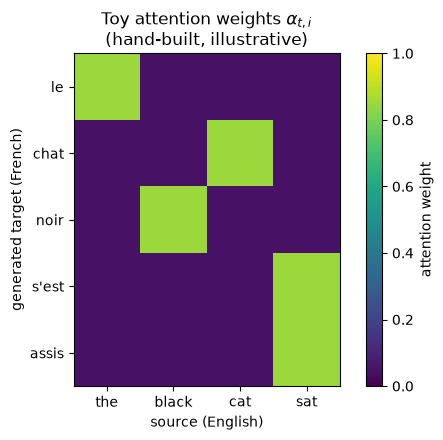

In [2]:

import numpy as np
import matplotlib.pyplot as plt

src_words = ["the", "black", "cat", "sat"]
tgt_words = ["le", "chat", "noir", "s'est", "assis"]

# A hand-built "toy alignment strength" matrix standing in for real learned
# scores: rows = target words being generated, columns = source words.
# This is illustrative only (not learned) -- it encodes the true French
# word order (noun/adjective swap: "cat black" -> "chat noir") so the
# resulting heatmap shows what a *correct* alignment pattern looks like.
toy_alpha = np.array([
    [0.85, 0.05, 0.05, 0.05],   # le      <- the
    [0.05, 0.05, 0.85, 0.05],   # chat    <- cat
    [0.05, 0.85, 0.05, 0.05],   # noir    <- black
    [0.05, 0.05, 0.05, 0.85],   # s'est   <- sat
    [0.05, 0.05, 0.05, 0.85],   # assis   <- sat
])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(toy_alpha, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(src_words))); ax.set_xticklabels(src_words)
ax.set_yticks(range(len(tgt_words))); ax.set_yticklabels(tgt_words)
ax.set_xlabel("source (English)"); ax.set_ylabel("generated target (French)")
ax.set_title("Toy attention weights $\\alpha_{t,i}$\n(hand-built, illustrative)")
plt.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.savefig("toy_attention_heatmap.png", dpi=130)
plt.show()



Read this the way you'll read the real one in §5: **each row sums to 1**
(it's a softmax output) and shows, for one generated word, how much weight
the decoder put on each source word. Notice `"noir"` (black) attends
strongly to `"black"` even though it appears in a *different position*
relative to `"cat"` than in English — this is exactly the reordering
flexibility a fixed single context vector (§3.2) can't express, but a
per-step weighted sum (§3.3) can. Now let's see if a real trained model
recovers a pattern anywhere near this coherent from real data.



## 5. Implementation: a real encoder-decoder-with-attention NMT model

We'll train on real English-French sentence pairs from **OPUS Books**
(Tiedemann, 2012) — a corpus of aligned sentences from public-domain
literary translations, served via Hugging Face's `datasets` library. To
keep training time reasonable on a CPU, we filter to a subset of **short**
sentence pairs (a real, small-scale training run, not a toy — just a
budget-conscious one) and use small embedding/hidden dimensions. The
translations this produces will be rough — that's expected and reported
honestly in §7 — the goal is a real, working training loop and a real,
readable attention pattern, not state-of-the-art translation quality.

### 5.1 Loading and filtering real data


In [3]:

import re
import random
from collections import Counter

from datasets import load_dataset

random.seed(0)

raw = load_dataset("Helsinki-NLP/opus_books", "en-fr", split="train")
print(f"Full OPUS Books en-fr corpus: {len(raw):,} sentence pairs")

def tokenize(text):
    # Simple regex word/punctuation tokenizer -- same spirit as the
    # rule-based tokenizer from this domain's tokenization tutorial, just
    # inlined here since we only need whitespace + punctuation splitting.
    return re.findall(r"[A-Za-zÀ-ÿ]+|[.,!?;]", text.lower())

MAX_LEN = 10   # keep sentences short: faster training, more legible attention plots
MIN_LEN = 3

pairs = []
for ex in raw:
    en = tokenize(ex["translation"]["en"])
    fr = tokenize(ex["translation"]["fr"])
    if MIN_LEN <= len(en) <= MAX_LEN and MIN_LEN <= len(fr) <= MAX_LEN:
        pairs.append((en, fr))
    if len(pairs) >= 6000:
        break

random.shuffle(pairs)
train_pairs = pairs[:4500]
val_pairs = pairs[4500:5000]
test_pairs = pairs[5000:5030]

print(f"Filtered to short pairs (<= {MAX_LEN} tokens each side): {len(pairs):,} kept")
print(f"train={len(train_pairs)}  val={len(val_pairs)}  test(held-out for translation)={len(test_pairs)}")
print("\nExample pairs:")
for en, fr in train_pairs[:3]:
    print(" EN:", " ".join(en))
    print(" FR:", " ".join(fr))
    print()


Full OPUS Books en-fr corpus: 127,085 sentence pairs


Filtered to short pairs (<= 10 tokens each side): 6,000 kept
train=4500  val=500  test(held-out for translation)=30

Example pairs:
 EN: populus me sibilat , at mihi plaudo ,
 FR: populus me sibilat , at mihi plaudo

 EN: la réponse fut concluante .
 FR: the answer was conclusive .

 EN: chapitre iv les renseignements fournis par john rance
 FR: chapter iv . what john rance had to tell .




### 5.2 Building word-level vocabularies

Same idea as the whole-word tokenizers from this domain's tokenization
tutorial: split on whitespace/punctuation, then cap the vocabulary to
frequent words, mapping everything else to `<unk>`. We build one
vocabulary per language, since English and French word frequencies are
naturally very different.


In [4]:

PAD, UNK, SOS, EOS = "<pad>", "<unk>", "<sos>", "<eos>"

def build_vocab(token_lists, min_freq=2, max_size=5000):
    counts = Counter(tok for toks in token_lists for tok in toks)
    itos = [PAD, UNK, SOS, EOS]
    for word, freq in counts.most_common():
        if freq < min_freq or len(itos) >= max_size:
            continue
        itos.append(word)
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos

src_stoi, src_itos = build_vocab([en for en, fr in train_pairs])
tgt_stoi, tgt_itos = build_vocab([fr for en, fr in train_pairs])

print(f"English (source) vocab size: {len(src_itos):,}")
print(f"French (target) vocab size:  {len(tgt_itos):,}")

def encode(tokens, stoi, add_sos_eos=False):
    ids = [stoi.get(t, stoi[UNK]) for t in tokens]
    if add_sos_eos:
        ids = [stoi[SOS]] + ids + [stoi[EOS]]
    return ids


English (source) vocab size: 1,621
French (target) vocab size:  1,786



### 5.3 The encoder, the Bahdanau attention module, and the decoder

This is a direct implementation of §3.1 / §3.3: `Encoder` reads the source
sentence with a GRU and keeps **every** hidden state (not just the last
one); `Attention` implements the additive scoring function
$v^\top\tanh(W_1 h^{dec} + W_2 h^{enc})$ and the softmax normalization from
§3.3; `Decoder` uses the resulting per-step context vector $c_t$, alongside
the previous target token, to generate the next word.


In [5]:

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
device = torch.device("cpu")

EMB_DIM = 128
HID_DIM = 128
PAD_IDX = src_stoi[PAD]

class Encoder(nn.Module):
    # Reads the source sentence, returns ALL hidden states (not just the last).
    def __init__(self, vocab_size, emb_dim=EMB_DIM, hid_dim=HID_DIM):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):                       # src: (batch, src_len)
        embedded = self.embedding(src)              # (batch, src_len, emb_dim)
        enc_outputs, hidden = self.gru(embedded)     # enc_outputs: (batch, src_len, hid_dim)
        return enc_outputs, hidden                   # hidden: (1, batch, hid_dim)


class BahdanauAttention(nn.Module):
    # score(h_dec, h_enc) = v^T tanh(W1 h_dec + W2 h_enc), then softmax over source positions.
    def __init__(self, hid_dim=HID_DIM):
        super().__init__()
        self.W1 = nn.Linear(hid_dim, hid_dim)
        self.W2 = nn.Linear(hid_dim, hid_dim)
        self.v = nn.Linear(hid_dim, 1)

    def forward(self, dec_hidden, enc_outputs, src_mask):
        # dec_hidden: (batch, hid_dim) -- decoder's previous hidden state h^dec_{t-1}
        # enc_outputs: (batch, src_len, hid_dim) -- all encoder hidden states h^enc_i
        dec_hidden = dec_hidden.unsqueeze(1)                          # (batch, 1, hid_dim)
        scores = self.v(torch.tanh(self.W1(dec_hidden) + self.W2(enc_outputs)))  # (batch, src_len, 1)
        scores = scores.squeeze(-1).masked_fill(src_mask == 0, float("-inf"))    # (batch, src_len) = e_{t,i}
        alpha = F.softmax(scores, dim=-1)                             # (batch, src_len) = alpha_{t,i}
        context = torch.bmm(alpha.unsqueeze(1), enc_outputs).squeeze(1)          # c_t = sum_i alpha_{t,i} h^enc_i
        return context, alpha


class AttnDecoder(nn.Module):
    # Generates one target token at a time, conditioned on y_{t-1}, s_{t-1}, and c_t.
    def __init__(self, vocab_size, emb_dim=EMB_DIM, hid_dim=HID_DIM):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(hid_dim)
        self.gru = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.out = nn.Linear(hid_dim * 2, vocab_size)

    def forward(self, prev_token, prev_hidden, enc_outputs, src_mask):
        embedded = self.embedding(prev_token).unsqueeze(1)            # (batch, 1, emb_dim)
        context, alpha = self.attention(prev_hidden.squeeze(0), enc_outputs, src_mask)
        gru_input = torch.cat([embedded, context.unsqueeze(1)], dim=-1)
        gru_out, hidden = self.gru(gru_input, prev_hidden)            # gru_out: (batch, 1, hid_dim)
        logits = self.out(torch.cat([gru_out.squeeze(1), context], dim=-1))  # (batch, vocab_size)
        return logits, hidden, alpha


encoder = Encoder(len(src_itos)).to(device)
decoder = AttnDecoder(len(tgt_itos)).to(device)
n_params = sum(p.numel() for p in list(encoder.parameters()) + list(decoder.parameters()))
print(f"Encoder + decoder parameters: {n_params:,}")


Encoder + decoder parameters: 1,175,547



### 5.4 Batching and the training loop (with teacher forcing)

Sentences in a batch have different lengths, so we pad to the batch's max
length and mask out padding positions in the attention scores (a padded
position should never receive attention weight, hence `masked_fill(...,
-inf)` before the softmax above). Training uses **teacher forcing** (§3.1):
at every decoder step, the *true* previous target token is fed in, and the
loss is the average per-token cross-entropy over the whole target sentence.


In [6]:

import time
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.data = [(encode(en, src_stoi), encode(fr, tgt_stoi, add_sos_eos=True)) for en, fr in pairs]
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def collate(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_len = max(len(s) for s in src_seqs)
    tgt_len = max(len(t) for t in tgt_seqs)
    src_padded = torch.full((len(batch), src_len), PAD_IDX, dtype=torch.long)
    tgt_padded = torch.full((len(batch), tgt_len), tgt_stoi[PAD], dtype=torch.long)
    for i, (s, t) in enumerate(zip(src_seqs, tgt_seqs)):
        src_padded[i, :len(s)] = torch.tensor(s, dtype=torch.long)
        tgt_padded[i, :len(t)] = torch.tensor(t, dtype=torch.long)
    return src_padded, tgt_padded

train_loader = DataLoader(TranslationDataset(train_pairs), batch_size=64, shuffle=True, collate_fn=collate)
val_loader = DataLoader(TranslationDataset(val_pairs), batch_size=64, shuffle=False, collate_fn=collate)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_stoi[PAD])

def run_epoch(loader, train=True):
    encoder.train(train); decoder.train(train)
    total_loss, n_batches = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        src_mask = (src != PAD_IDX).float()
        if train:
            optimizer.zero_grad()
        enc_outputs, hidden = encoder(src)
        loss = 0.0
        input_token = tgt[:, 0]                    # <sos>
        for t in range(1, tgt.size(1)):
            logits, hidden, _ = decoder(input_token, hidden, enc_outputs, src_mask)
            loss = loss + criterion(logits, tgt[:, t])
            input_token = tgt[:, t]                 # teacher forcing: feed the TRUE previous token
        loss = loss / (tgt.size(1) - 1)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 1.0)
            optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches

N_EPOCHS = 10
train_losses, val_losses = [], []
t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    tr_loss = run_epoch(train_loader, train=True)
    with torch.no_grad():
        va_loss = run_epoch(val_loader, train=False)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    print(f"epoch {epoch:2d}/{N_EPOCHS}  train loss {tr_loss:.3f}  val loss {va_loss:.3f}  "
          f"({time.time() - t0:.0f}s elapsed)")

print(f"\nTotal training time: {time.time() - t0:.0f}s")


epoch  1/10  train loss 4.519  val loss 3.335  (34s elapsed)


epoch  2/10  train loss 3.411  val loss 3.037  (72s elapsed)


epoch  3/10  train loss 3.061  val loss 2.821  (102s elapsed)


epoch  4/10  train loss 2.770  val loss 2.659  (139s elapsed)


epoch  5/10  train loss 2.512  val loss 2.545  (169s elapsed)


epoch  6/10  train loss 2.285  val loss 2.452  (196s elapsed)


epoch  7/10  train loss 2.089  val loss 2.394  (209s elapsed)


epoch  8/10  train loss 1.905  val loss 2.360  (228s elapsed)


epoch  9/10  train loss 1.738  val loss 2.331  (243s elapsed)


epoch 10/10  train loss 1.577  val loss 2.324  (257s elapsed)

Total training time: 257s



### 5.5 The real training loss curve


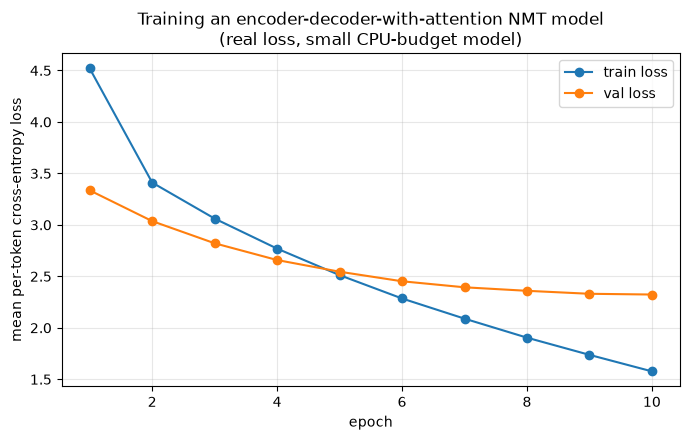

In [7]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, N_EPOCHS + 1), train_losses, marker="o", label="train loss")
ax.plot(range(1, N_EPOCHS + 1), val_losses, marker="o", label="val loss")
ax.set_xlabel("epoch")
ax.set_ylabel("mean per-token cross-entropy loss")
ax.set_title("Training an encoder-decoder-with-attention NMT model\n(real loss, small CPU-budget model)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=130)
plt.show()



### 5.6 Translating real held-out sentences, and extracting real attention weights

Greedy decoding: at each step, feed in the model's own highest-probability
previous token (not teacher forcing anymore — this is inference, we don't
have the true French translation to feed in), and stop at `<eos>` or a
maximum length. We also record the attention weights $\alpha_{t,i}$ at
every step, which is exactly what makes the heatmap below possible.


In [8]:

def translate(sentence_tokens, max_len=15):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        src_ids = torch.tensor([encode(sentence_tokens, src_stoi)], dtype=torch.long)
        src_mask = torch.ones_like(src_ids, dtype=torch.float)
        enc_outputs, hidden = encoder(src_ids)

        input_token = torch.tensor([tgt_stoi[SOS]], dtype=torch.long)
        output_tokens, attn_weights = [], []
        for _ in range(max_len):
            logits, hidden, alpha = decoder(input_token, hidden, enc_outputs, src_mask)
            next_id = logits.argmax(dim=-1)
            attn_weights.append(alpha.squeeze(0).numpy())
            if next_id.item() == tgt_stoi[EOS]:
                break
            output_tokens.append(tgt_itos[next_id.item()])
            input_token = next_id
    return output_tokens, np.array(attn_weights)

import numpy as np

print("Real held-out translations (this is a small, undertrained model -- expect rough output):\n")
translations = []
for en, fr_true in test_pairs[:8]:
    pred_tokens, _ = translate(en)
    translations.append((en, fr_true, pred_tokens))
    print(f"SRC (en):        {' '.join(en)}")
    print(f"REF (fr, true):  {' '.join(fr_true)}")
    print(f"MODEL (fr, pred):{' '.join(pred_tokens)}")
    print()


Real held-out translations (this is a small, undertrained model -- expect rough output):

SRC (en):        well , it was up there .
REF (fr, true):  eh bien , il venait de là .
MODEL (fr, pred):c était un <unk> de <unk> .

SRC (en):        i assured him that i should not .
REF (fr, true):  je lui promis qu il n en serait rien .
MODEL (fr, pred):je ne suis pas qu je ne <unk> pas .

SRC (en):        where are you , robin crusoe ?
REF (fr, true):  où êtes vous ? , robin crusoe ?
MODEL (fr, pred):où êtes vous <unk> , <unk> ?

SRC (en):        she said four months .
REF (fr, true):  elle me dit quatre mois .
MODEL (fr, pred):elle dit elle dit elle .

SRC (en):        how i long to see her again !
REF (fr, true):  comme je serais heureuse de la revoir !
MODEL (fr, pred):je suis <unk> de la <unk> !

SRC (en):        from tarbes , said d artagnan .
REF (fr, true):  de tarbes , dit d artagnan . . . .
MODEL (fr, pred):<unk> , dit la <unk> .

SRC (en):        my dear aunt , this is being serious 


### 5.7 The attention heatmap: which source words did the model actually attend to?

This is the single most important visual in this tutorial. We pick one
example translation and plot the real, extracted attention weight matrix
$\alpha_{t,i}$ — source words on one axis, the model's own generated
target words on the other — exactly as previewed on toy data in §4.


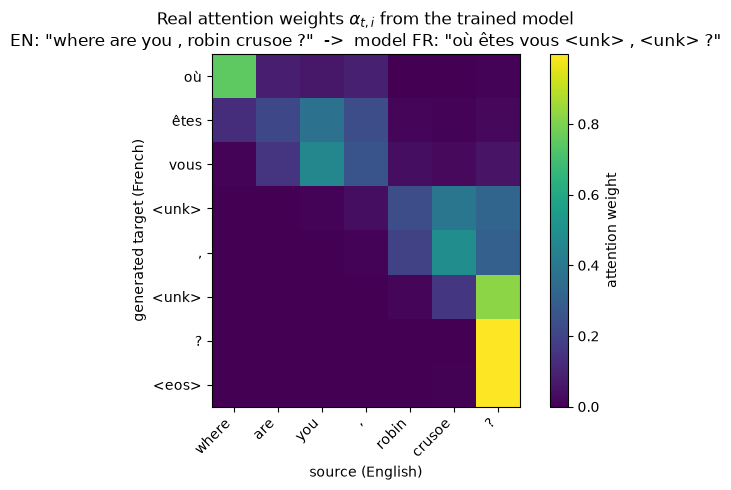

Reference (true) French translation: où êtes vous ? , robin crusoe ?


In [9]:

example_idx = 2
src_example, fr_true_example, pred_tokens = translations[example_idx]
_, attn_matrix = translate(src_example)   # re-run to get attention weights for this example

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(attn_matrix[:, :len(src_example)], cmap="viridis", vmin=0, vmax=attn_matrix.max())
ax.set_xticks(range(len(src_example)))
ax.set_xticklabels(src_example, rotation=45, ha="right")
ax.set_yticks(range(len(pred_tokens) + (1 if attn_matrix.shape[0] > len(pred_tokens) else 0)))
ax.set_yticklabels((pred_tokens + ["<eos>"])[:attn_matrix.shape[0]])
ax.set_xlabel("source (English)")
ax.set_ylabel("generated target (French)")
ax.set_title("Real attention weights $\\alpha_{t,i}$ from the trained model\n"
              f"EN: \"{' '.join(src_example)}\"  ->  model FR: \"{' '.join(pred_tokens)}\"")
plt.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.savefig("real_attention_heatmap.png", dpi=130)
plt.show()

print("Reference (true) French translation:", " ".join(fr_true_example))



## 6. Use cases

- **This exact architecture was the dominant neural machine translation
  approach** from roughly 2015-2017: Bahdanau/Luong-style
  encoder-decoder-with-attention models replaced the previous generation
  of statistical phrase-based MT systems, and powered early production
  systems — most notably **Google's first neural machine translation
  system (GNMT, 2016)**, an LSTM encoder-decoder with attention (at much
  larger scale than this tutorial's CPU-budget model), deployed for real
  Google Translate traffic.
- **The Transformer (Vaswani et al., 2017)** — this domain's next tutorial
  — replaced the recurrent encoder/decoder with pure self-attention, but
  kept the encoder-decoder *shape* (an encoder stack, a decoder stack, and
  cross-attention between them) and the attention mechanism you derived in
  §3.3 essentially unchanged in spirit. Understanding this tutorial's
  attention mechanism is a direct prerequisite for understanding the
  Transformer's.
- **The encoder-decoder-with-attention shape generalizes far beyond
  translation** to any sequence-transduction task where the output is a
  *different* sequence from the input: **text summarization** (encode a
  long document, decode a short summary), **speech-to-text** (encode
  audio features, decode a transcript), and **image captioning** (encode
  an image with a CNN, decode a caption with an attention-augmented RNN/
  Transformer decoder) all reuse this same read-then-generate-with-
  attention pattern.



## 7. Limitations & debates

- **Sequential computation is still the core bottleneck.** Just like this
  domain's RNN/LSTM language-modeling tutorial already flagged: every
  encoder step depends on the previous encoder step, and every decoder
  step depends on the previous decoder step, so **training cannot be
  parallelized across the sequence dimension** — each `for t in
  range(...)` loop in §5.4/§5.6 is a genuine, unavoidable sequential
  dependency, not an implementation shortcut. At scale (millions of long
  sentences) this becomes a real wall-clock bottleneck, and is the
  single biggest practical reason the field moved to the Transformer.
- **Attention doesn't remove the "read everything first" requirement,
  and it isn't free.** The decoder still can't start generating until the
  *entire* source sentence has been encoded (the encoder's `for`-loop over
  $i = 1, \dots, n$ must finish first) — attention only changes *what the
  decoder does with* the encoder's output, not *when* it becomes
  available. And computing attention itself is $O(n)$ per decoder step
  (one score $e_{t,i}$ per encoder position), so a full translation is
  $O(nm)$ total. The Transformer generalizes the same
  alignment-score-then-weighted-sum mechanism to *every* pair of
  positions in *both* sequences (self-attention), which removes the
  recurrent dependency entirely and parallelizes across positions — but
  at $O(n^2)$ total self-attention cost per sequence, a real tradeoff
  (sequential-but-linear vs. parallel-but-quadratic) worth naming
  explicitly, not a strict win either way.
- **This tutorial's own model is a small, honestly-reported, undertrained
  demo, not a production system.** Trained on roughly 4,500 sentence pairs
  capped at 10 tokens per side for 10 epochs with a 128-dimensional hidden
  state on a CPU, its translations in §5.6 are frequently ungrammatical or only
  loosely related to the reference — that's the honest, expected result
  of this training budget, not a bug to paper over. Real production NMT
  systems train on tens of millions of sentence pairs, with far larger
  models, for days on GPU/TPU clusters.
- **Rigorously evaluating machine translation quality is itself a
  nontrivial, debated problem** that this tutorial does not attempt.
  **BLEU** (Papineni et al., 2002), the traditional automatic MT metric,
  compares n-gram overlap between a candidate translation and one or more
  reference translations — but it's well documented that BLEU
  **correlates imperfectly with human judgments of translation quality**
  (it can penalize a fluent, correct paraphrase that simply doesn't share
  the reference's exact n-grams, and reward disfluent output that happens
  to overlap lexically), which is why MT research increasingly reports
  learned/neural metrics (e.g. COMET, BLEURT) alongside or instead of BLEU
  — an active, ongoing methodological debate in the field, not a solved
  question.



## 8. References

- Sutskever, I., Vinyals, O., Le, Q.V. (2014). *Sequence to Sequence
  Learning with Neural Networks.* NeurIPS 2014. (The basic encoder-decoder
  architecture, §3.1.)
- Cho, K., van Merrienboer, B., Bahdanau, D., Bengio, Y. (2014). *On the
  Properties of Neural Machine Translation: Encoder-Decoder Approaches.*
  SSST-8. (The fixed-context-vector, degrades-with-sentence-length
  observation, §3.2.)
- Bahdanau, D., Cho, K., Bengio, Y. (2015). *Neural Machine Translation by
  Jointly Learning to Align and Translate.* ICLR 2015. (The attention
  mechanism, §3.3.)
- Luong, M.T., Pham, H., Manning, C.D. (2015). *Effective Approaches to
  Attention-based Neural Machine Translation.* EMNLP 2015. (Alternative,
  simpler scoring functions including dot-product attention.)
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All
  You Need.* NeurIPS 2017. (The Transformer; this domain's next tutorial.)
- Tiedemann, J. (2012). *Parallel Data, Tools and Interfaces in OPUS.*
  LREC 2012. (Source of the `opus_books` English-French corpus used in
  §5.)
- Wu, Y., Schuster, M., Chen, Z., et al. (2016). *Google's Neural Machine
  Translation System: Bridging the Gap between Human and Machine
  Translation.* (GNMT, an early production deployment of this
  architecture, §6.)
- Papineni, K., Roukos, S., Ward, T., Zhu, W.J. (2002). *BLEU: a Method
  for Automatic Evaluation of Machine Translation.* ACL 2002. (§7's
  discussion of MT evaluation.)
